# Phase 6: Cleaning and exploratory analysis

The source window and valid order statuses are read from params.yaml. Revenue is delivered item price; freight remains separate. The dataset covers about 20 months, so yearly seasonality cannot be estimated.

In [1]:
from pathlib import Path
import sys
ROOT=Path.cwd()
if not (ROOT/'src').is_dir(): ROOT=ROOT.parent
if str(ROOT) not in sys.path: sys.path.insert(0,str(ROOT))
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from IPython.display import display
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.stats.outliers_influence import variance_inflation_factor
from src.cleaning import build_clean_tables
from src.config import ANALYSIS_START, ANALYSIS_END, DATA_PROCESSED, DOCS_DIR
from src.stats_tests import mann_whitney_effect, category_repeat_test, lateness_repeat_test, delay_score_spearman
clean_result=build_clean_tables()
display(clean_result['quality_summary'].style.format({'null_rate_before':'{:.2%}','null_rate_after':'{:.2%}'}))
d=DATA_PROCESSED/'clean'
items=pd.read_parquet(d/'orders_clean.parquet')
customers=pd.read_parquet(d/'customers_clean.parquet')
interactions=pd.read_parquet(d/'interactions_clean.parquet')
products=pd.read_parquet(d/'products_clean.parquet')
reviews=pd.read_parquet(d/'reviews_clean.parquet')
orders=items.sort_values(['order_id','order_item_id']).drop_duplicates('order_id').copy()
orders['delay_days']=orders.delivery_days-orders.estimated_days
daily=orders.set_index('purchase_ts').resample('D').order_id.nunique().asfreq('D',fill_value=0).rename('orders')
FIG=DOCS_DIR/'figures'; FIG.mkdir(parents=True,exist_ok=True)
sns.set_theme(style='whitegrid')
def save(fig,name):
    fig.tight_layout(); fig.savefig(FIG/name,dpi=100,bbox_inches='tight'); display(fig); plt.close(fig)
start=pd.Timestamp(ANALYSIS_START); end=pd.Timestamp(ANALYSIS_END)+pd.Timedelta(days=1)


orders_clean: VALID (112,279 rows)
customers_clean: VALID (96,211 rows)
interactions_clean: VALID (99,915 rows)
products_clean: VALID (32,951 rows)


reviews_clean: VALID (95,568 rows)
       table  rows_before  rows_after  null_rate_before  null_rate_after  duplicate_rows_before  duplicate_rows_after
      orders       112279      112279          0.003708         0.003708                      0                     0
   customers        96211       96211          0.001223         0.001223                      0                     0
interactions        99915       99915          0.002000         0.002000                      0                     0
    products        32951       32951          0.020980         0.018188                      0                     0
     reviews        96095       95568          0.119441         0.119357                      0                     0
Order inconsistency flags:
                           issue  count
               price_nonpositive      0
           freight_exceeds_price   4116
       delivered_before_purchase      0
        approved_before_purchase      0
       estimated_before_purcha

,table,rows_before,rows_after,null_rate_before,null_rate_after,duplicate_rows_before,duplicate_rows_after
0,orders,112279,112279,0.37%,0.37%,0,0
1,customers,96211,96211,0.12%,0.12%,0,0
2,interactions,99915,99915,0.20%,0.20%,0,0
3,products,32951,32951,2.10%,1.82%,0,0
4,reviews,96095,95568,11.94%,11.94%,0,0


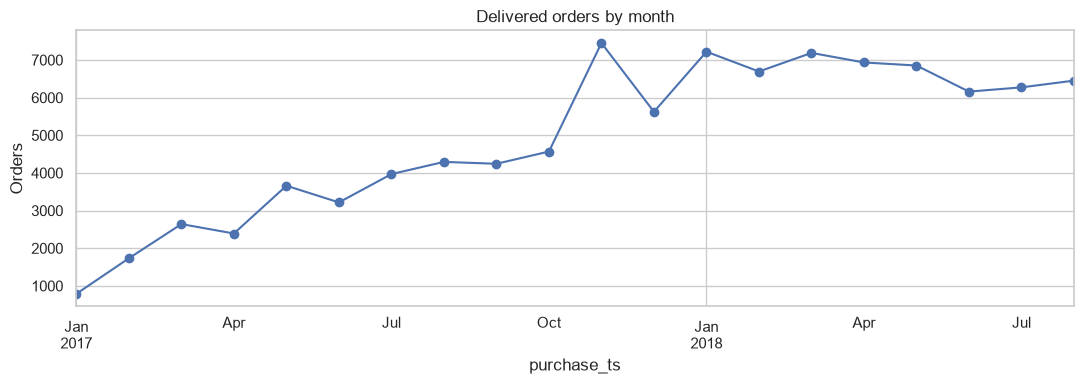

In [2]:
m=orders.groupby(orders.purchase_ts.dt.to_period('M')).order_id.nunique()
fig,ax=plt.subplots(figsize=(11,4)); m.plot(ax=ax,marker='o'); ax.set(title='Delivered orders by month',ylabel='Orders'); save(fig,'orders_monthly.png')

November 2017 is the peak month at **7,451 delivered orders**.

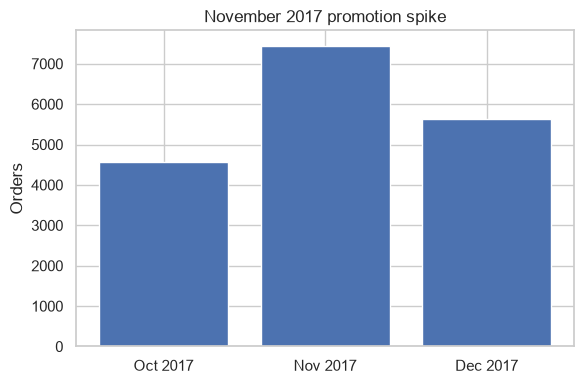

In [3]:
nov=m.get(pd.Period('2017-11'),0); octv=m.get(pd.Period('2017-10'),0); decv=m.get(pd.Period('2017-12'),0)
fig,ax=plt.subplots(figsize=(6,4)); ax.bar(['Oct 2017','Nov 2017','Dec 2017'],[octv,nov,decv]); ax.set(title='November 2017 promotion spike',ylabel='Orders'); save(fig,'black_friday_spike.png')

November 2017 had **46.2% more orders** than the average of October and December (7,451 vs 5,096).

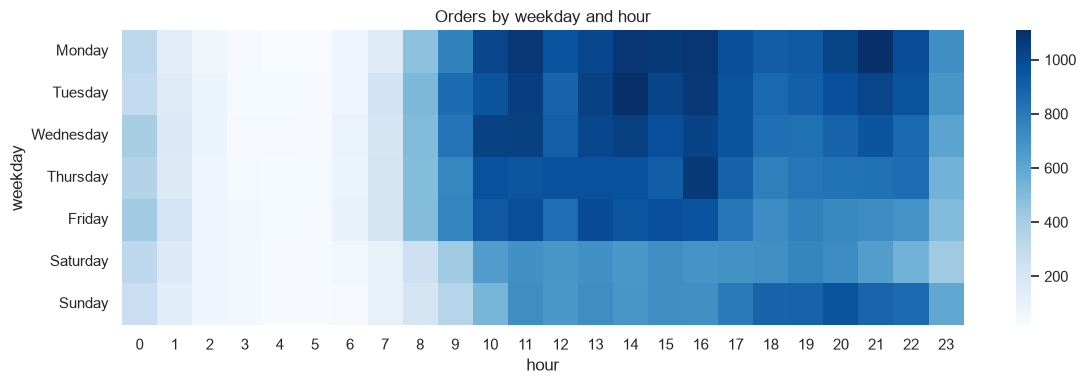

In [4]:
orders['weekday']=orders.purchase_ts.dt.day_name(); orders['hour']=orders.purchase_ts.dt.hour
heat=orders.pivot_table(index='weekday',columns='hour',values='order_id',aggfunc='nunique',fill_value=0,observed=False)
fig,ax=plt.subplots(figsize=(12,4)); sns.heatmap(heat.reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']),cmap='Blues',ax=ax); ax.set(title='Orders by weekday and hour'); save(fig,'weekday_hour_heatmap.png')

The busiest weekday/hour cell is **Tuesday at 14:00**.

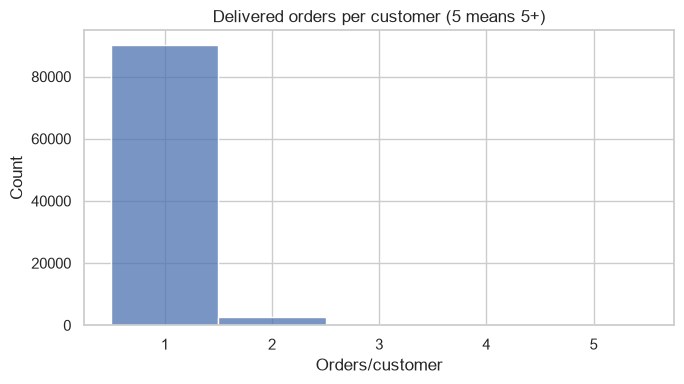

In [5]:
nper=customers.groupby('customer_unique_id').order_id.nunique()
fig,ax=plt.subplots(figsize=(7,4)); sns.histplot(nper.clip(upper=5),discrete=True,ax=ax); ax.set(title='Delivered orders per customer (5 means 5+)',xlabel='Orders/customer'); save(fig,'orders_per_customer.png')

Only **3.00% of 93,104 customers** placed at least two delivered orders.

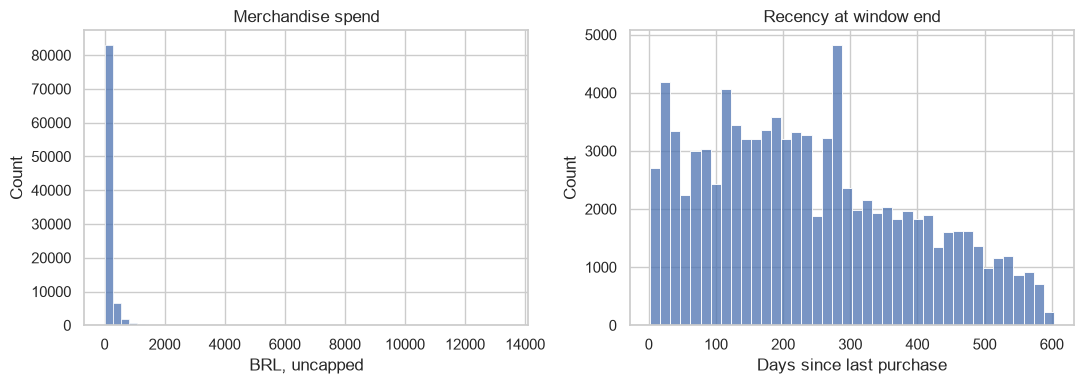

In [6]:
spend=customers.groupby('customer_unique_id').item_revenue.sum(); last=customers.groupby('customer_unique_id').purchase_ts.max(); recency=(end-last).dt.days
fig,axes=plt.subplots(1,2,figsize=(11,4)); sns.histplot(spend,bins=50,ax=axes[0]); axes[0].set(title='Merchandise spend',xlabel='BRL, uncapped'); sns.histplot(recency,bins=40,ax=axes[1]); axes[1].set(title='Recency at window end',xlabel='Days since last purchase'); save(fig,'customer_spend_recency.png')

Median merchandise spend is **BRL 89.70** per customer, excluding freight.

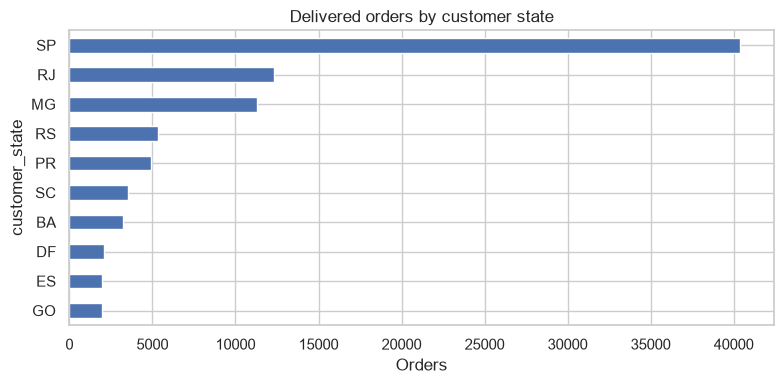

In [7]:
state=customers.groupby('customer_state',observed=True).order_id.nunique().sort_values(ascending=False).head(10)
fig,ax=plt.subplots(figsize=(8,4)); state.sort_values().plot.barh(ax=ax); ax.set(title='Delivered orders by customer state',xlabel='Orders'); save(fig,'state_concentration.png')

S?o Paulo and Rio de Janeiro together account for **52,716 delivered orders**.

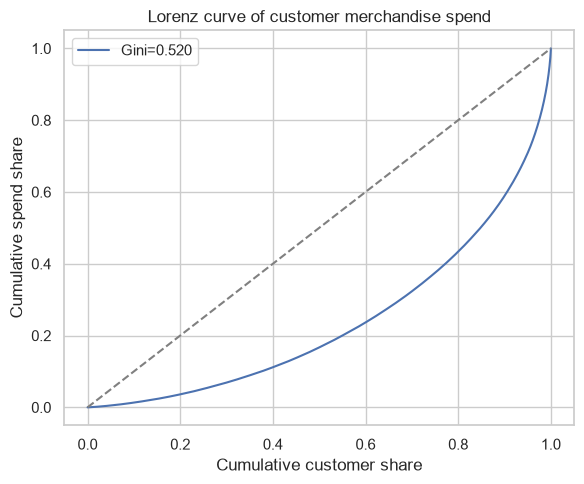

In [8]:
x=np.sort(spend.to_numpy()); y=np.insert(np.cumsum(x)/x.sum(),0,0); pop=np.linspace(0,1,len(y)); gini=1-2*np.trapezoid(y,pop)
fig,ax=plt.subplots(figsize=(6,5)); ax.plot(pop,y,label=f'Gini={gini:.3f}'); ax.plot([0,1],[0,1],ls='--',color='gray'); ax.set(title='Lorenz curve of customer merchandise spend',xlabel='Cumulative customer share',ylabel='Cumulative spend share'); ax.legend(); save(fig,'customer_spend_lorenz.png')

The customer-spend **Gini is 0.520**, showing substantial concentration across buyers.

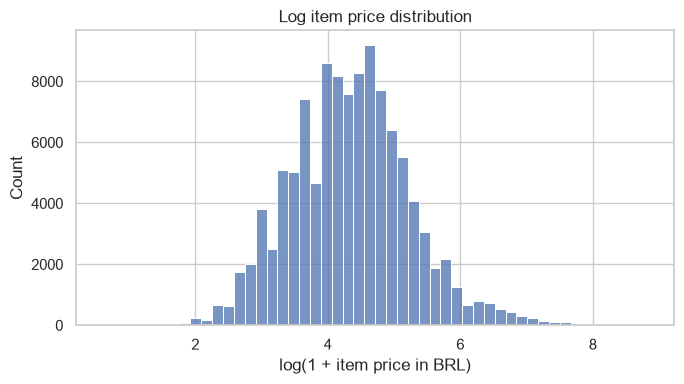

In [9]:
fig,ax=plt.subplots(figsize=(7,4)); sns.histplot(np.log1p(items.price.clip(lower=0)),bins=50,ax=ax); ax.set(title='Log item price distribution',xlabel='log(1 + item price in BRL)'); save(fig,'product_log_price.png')

The median uncapped item price is **BRL 79.00**.

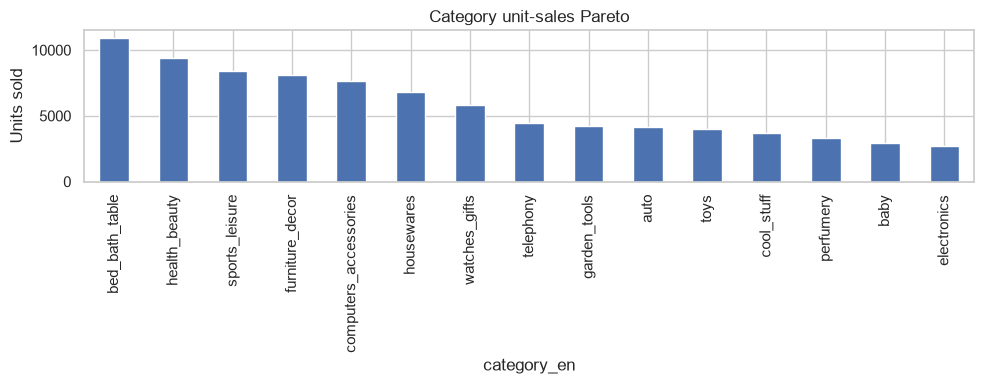

In [10]:
cat=products.groupby('category_en',observed=True).units_sold.sum().sort_values(ascending=False).dropna(); top=cat.head(15)
fig,ax=plt.subplots(figsize=(10,4)); top.plot.bar(ax=ax); ax.set(title='Category unit-sales Pareto',ylabel='Units sold'); save(fig,'category_pareto.png')

The top ten product categories contribute **64.6% of observed units sold**.

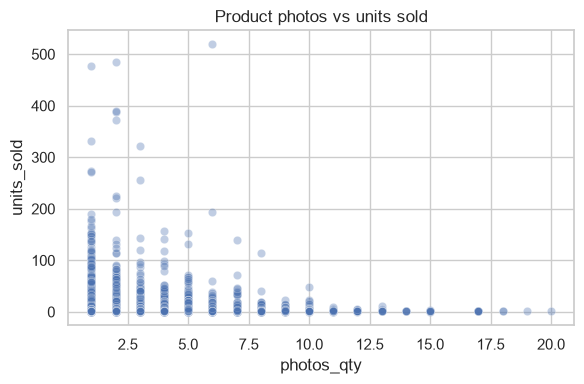

In [11]:
fig,ax=plt.subplots(figsize=(6,4)); sns.scatterplot(data=products,x='photos_qty',y='units_sold',alpha=.35,ax=ax); ax.set(title='Product photos vs units sold'); save(fig,'photos_vs_units.png')

Photo count and units sold have **Spearman rho = 0.018**, a negligible association.

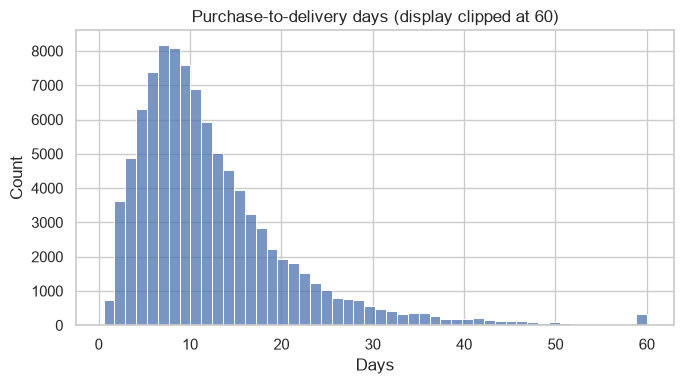

In [12]:
delivery=orders.dropna(subset=['delivery_days'])
fig,ax=plt.subplots(figsize=(7,4)); sns.histplot(delivery.delivery_days.clip(upper=60),bins=50,ax=ax); ax.set(title='Purchase-to-delivery days (display clipped at 60)',xlabel='Days'); save(fig,'delivery_days.png')

Median observed purchase-to-delivery time is **10.21 days**.

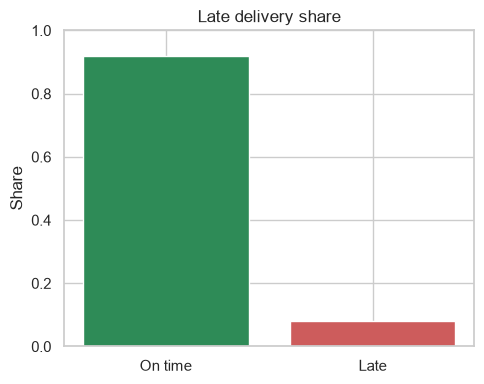

In [13]:
late=orders.is_late.dropna().astype(bool); rate=late.mean()
fig,ax=plt.subplots(figsize=(5,4)); ax.bar(['On time','Late'],[(~late).mean(),rate],color=['seagreen','indianred']); ax.set(title='Late delivery share',ylabel='Share',ylim=(0,1)); save(fig,'late_rate.png')

The recorded late-delivery rate is **8.13%** among orders with a lateness label.

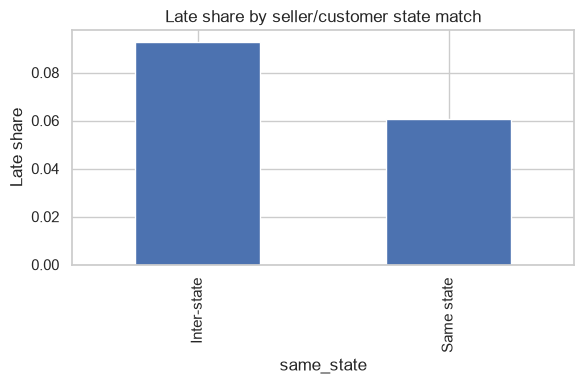

In [14]:
delivery['same_state']=delivery.customer_state.astype('string').eq(delivery.seller_state.astype('string'))
route=delivery.groupby('same_state').is_late.mean().rename(index={True:'Same state',False:'Inter-state'})
fig,ax=plt.subplots(figsize=(6,4)); route.plot.bar(ax=ax); ax.set(title='Late share by seller/customer state match',ylabel='Late share'); save(fig,'late_same_interstate.png')

Inter-state orders are late **9.29%** of the time, vs **6.07%** for same-state orders.

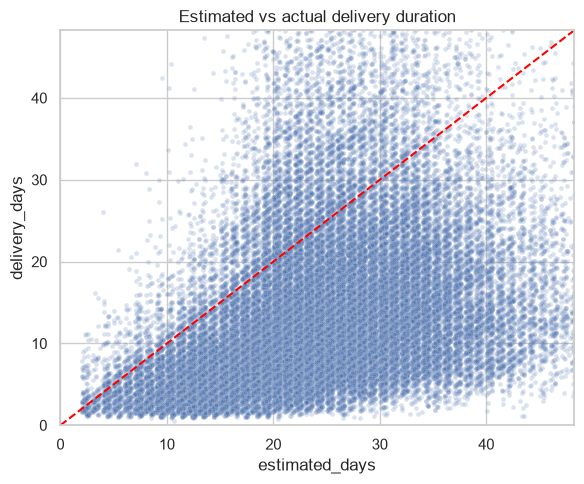

In [15]:
fig,ax=plt.subplots(figsize=(6,5)); sns.scatterplot(data=delivery,x='estimated_days',y='delivery_days',alpha=.2,s=12,ax=ax); lim=max(delivery.estimated_days.quantile(.99),delivery.delivery_days.quantile(.99)); ax.plot([0,lim],[0,lim],color='red',ls='--'); ax.set(xlim=(0,lim),ylim=(0,lim),title='Estimated vs actual delivery duration'); save(fig,'estimated_vs_actual.png')

Median estimated duration is **23.22 days**, compared with **10.21 actual days**.

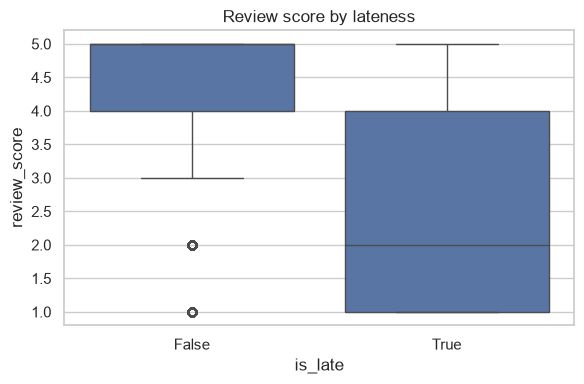

In [16]:
rv=reviews.dropna(subset=['is_late','review_score'])
fig,ax=plt.subplots(figsize=(6,4)); sns.boxplot(data=rv,x='is_late',y='review_score',ax=ax); ax.set(title='Review score by lateness'); save(fig,'lateness_review_score.png')

The median review score is **5 in both lateness groups**; compare the full distributions and effect size.

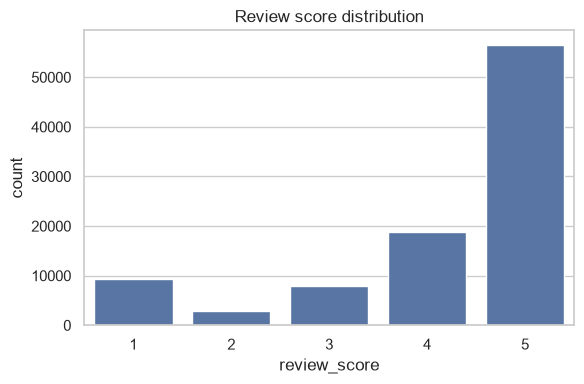

In [17]:
fig,ax=plt.subplots(figsize=(6,4)); sns.countplot(data=reviews,x='review_score',ax=ax); ax.set(title='Review score distribution'); save(fig,'review_score_distribution.png')

Five-star reviews are **59.22%** of order-level reviews.

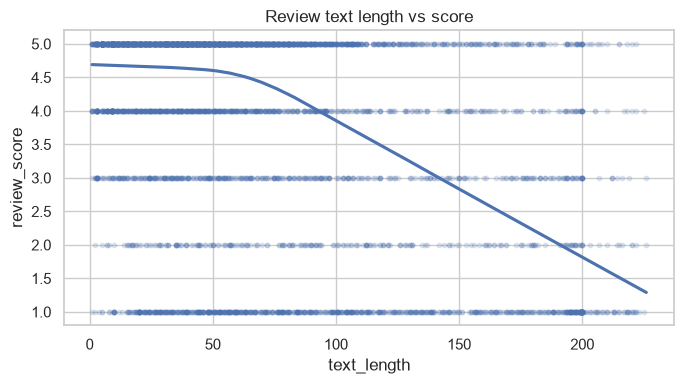

In [18]:
txt=reviews.dropna(subset=['review_text']).copy(); txt['text_length']=txt.review_text.str.len(); sample=txt.sample(min(5000,len(txt)),random_state=42)
fig,ax=plt.subplots(figsize=(7,4)); sns.regplot(data=sample,x='text_length',y='review_score',lowess=True,scatter_kws={'alpha':.15,'s':10},ax=ax); ax.set(title='Review text length vs score'); save(fig,'review_text_length_score.png')

Among reviews with text, length and score have **Spearman rho = -0.334**.

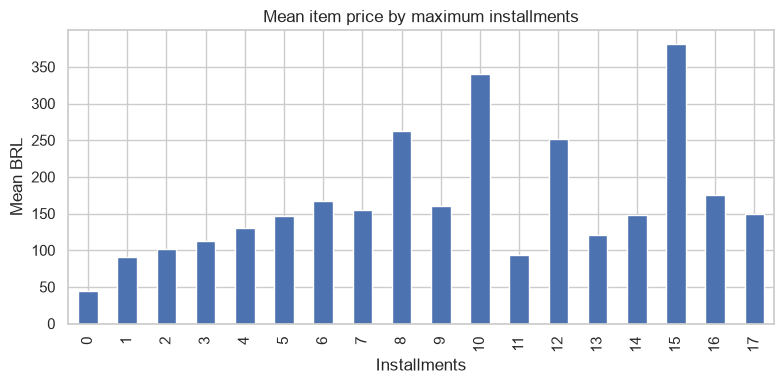

In [19]:
ins=orders.dropna(subset=['max_installments']).groupby('max_installments').price.mean().head(18)
fig,ax=plt.subplots(figsize=(8,4)); ins.plot.bar(ax=ax); ax.set(title='Mean item price by maximum installments',xlabel='Installments',ylabel='Mean BRL'); save(fig,'installments_order_value.png')

Installment count and item price have **Spearman rho = 0.360**; this is association, not a payment effect.

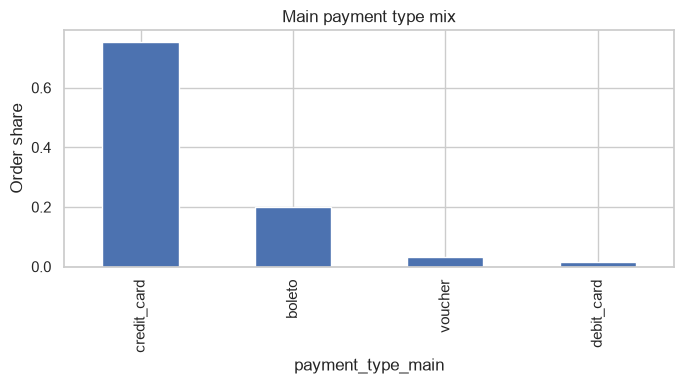

In [20]:
mix=orders.payment_type_main.value_counts(normalize=True)
fig,ax=plt.subplots(figsize=(7,4)); mix.plot.bar(ax=ax); ax.set(title='Main payment type mix',ylabel='Order share'); save(fig,'payment_type_mix.png')

Credit card is the main payment type for **75.4% of delivered orders**.

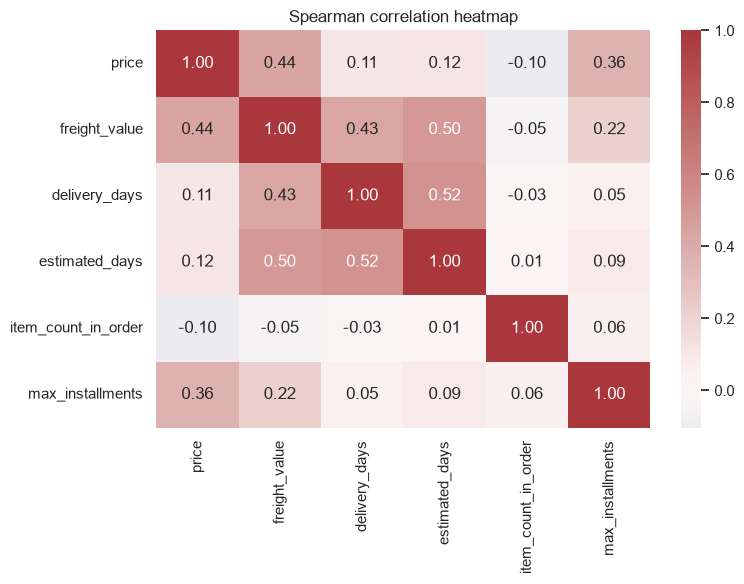

,price,freight_value,delivery_days,estimated_days,item_count_in_order,max_installments
price,1.000,0.439,0.110,0.117,-0.104,0.360
freight_value,0.439,1.000,0.430,0.497,-0.046,0.220
delivery_days,0.110,0.430,1.000,0.522,-0.026,0.052
estimated_days,0.117,0.497,0.522,1.000,0.011,0.093
item_count_in_order,-0.104,-0.046,-0.026,0.011,1.000,0.057
max_installments,0.360,0.220,0.052,0.093,0.057,1.000


In [21]:
numeric=orders[['price','freight_value','delivery_days','estimated_days','item_count_in_order','max_installments']].copy(); corr=numeric.corr(method='spearman')
fig,ax=plt.subplots(figsize=(8,6)); sns.heatmap(corr,annot=True,fmt='.2f',cmap='vlag',center=0,ax=ax); ax.set(title='Spearman correlation heatmap'); save(fig,'numeric_correlation_heatmap.png'); display(corr.round(3))

The numeric feature review covers **6 signals**; correlations are descriptive, not causal.

In [22]:
vdata=numeric.dropna().astype(float)
vif=pd.DataFrame({'feature':vdata.columns,'VIF':[variance_inflation_factor(vdata.to_numpy(),i) for i in range(vdata.shape[1])]})
display(vif.sort_values('VIF',ascending=False).round(2))

,feature,VIF
1,freight_value,1.35
0,price,1.31
3,estimated_days,1.24
2,delivery_days,1.19
5,max_installments,1.13
4,item_count_in_order,1.01


The VIF table checks **6 numeric features** for redundancy before linear modeling.

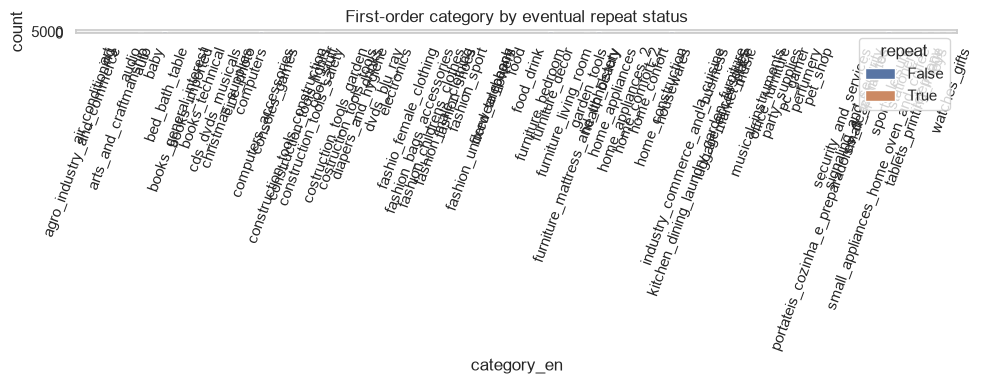

In [23]:
first=customers.sort_values('purchase_ts').drop_duplicates('customer_unique_id').copy(); counts=customers.groupby('customer_unique_id').order_id.nunique(); first['repeat']=first.customer_unique_id.map(counts).gt(1)
firstint=interactions.sort_values('purchase_ts').drop_duplicates(['customer_unique_id','order_id']).drop_duplicates('customer_unique_id')
first=first.merge(firstint[['customer_unique_id','category_en']],on='customer_unique_id',how='left'); common=first.category_en.value_counts().head(12).index
fig,ax=plt.subplots(figsize=(10,4)); sns.countplot(data=first[first.category_en.isin(common)],x='category_en',hue='repeat',ax=ax); ax.tick_params(axis='x',rotation=70); ax.set(title='First-order category by eventual repeat status'); save(fig,'repeat_first_category.png')

There are **2,789 repeat buyers** among 93,104 customers in the configured window.

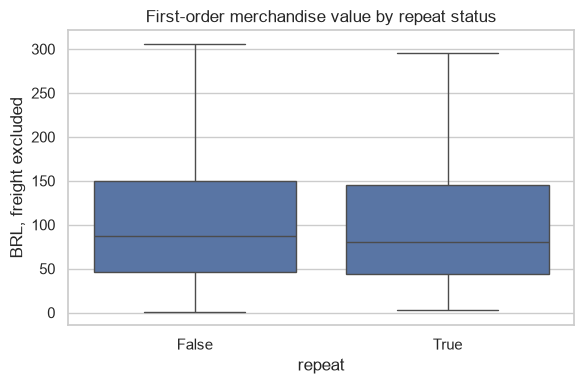

In [24]:
fig,ax=plt.subplots(figsize=(6,4)); sns.boxplot(data=first,x='repeat',y='item_revenue',showfliers=False,ax=ax); ax.set(title='First-order merchandise value by repeat status',ylabel='BRL, freight excluded'); save(fig,'repeat_first_value.png')

Median first-order merchandise value is **BRL 86.90 for one-time buyers and BRL 80.50 for eventual repeat buyers**.

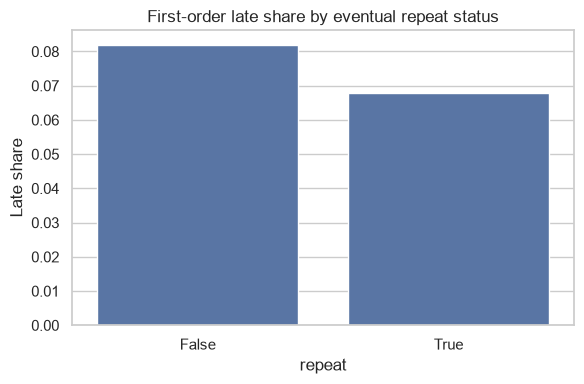

In [25]:
fig,ax=plt.subplots(figsize=(6,4)); sns.barplot(data=first,x='repeat',y='is_late',errorbar=None,ax=ax); ax.set(title='First-order late share by eventual repeat status',ylabel='Late share'); save(fig,'repeat_first_lateness.png')

First orders are late for **8.20% of one-time buyers and 6.78% of repeat buyers**.

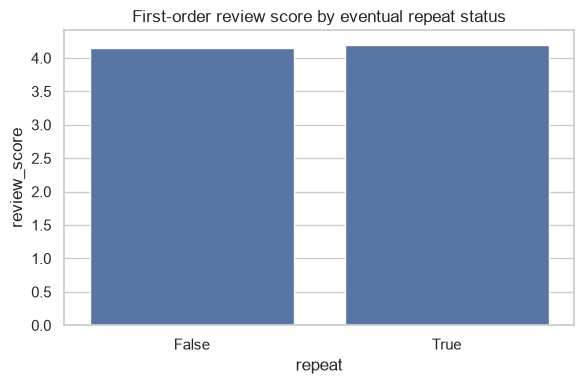

In [26]:
fig,ax=plt.subplots(figsize=(6,4)); sns.barplot(data=first,x='repeat',y='review_score',errorbar=None,ax=ax); ax.set(title='First-order review score by eventual repeat status'); save(fig,'repeat_first_review.png')

Mean first-order review scores differ by **0.05 points** (4.15 vs 4.20).

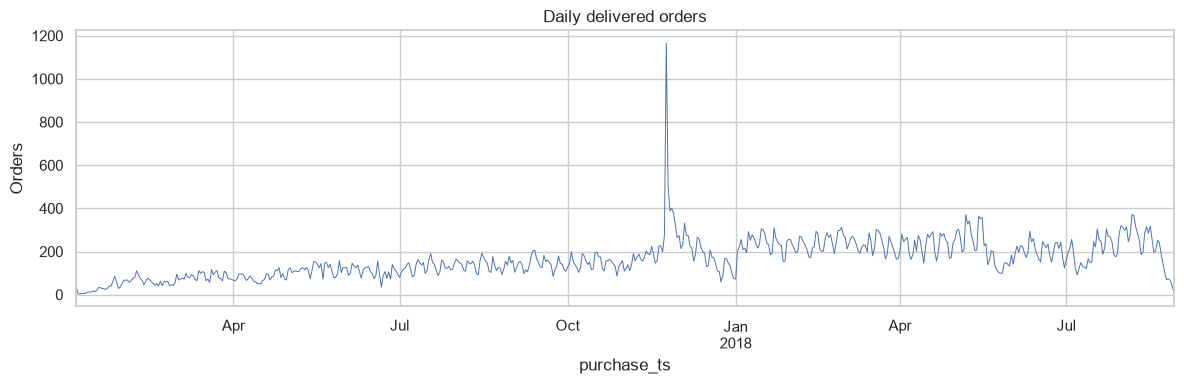

In [27]:
fig,ax=plt.subplots(figsize=(12,4)); daily.plot(ax=ax,lw=.7); ax.set(title='Daily delivered orders',ylabel='Orders'); save(fig,'daily_orders.png')

The daily series spans **about 20 months**, too short for annual seasonality.

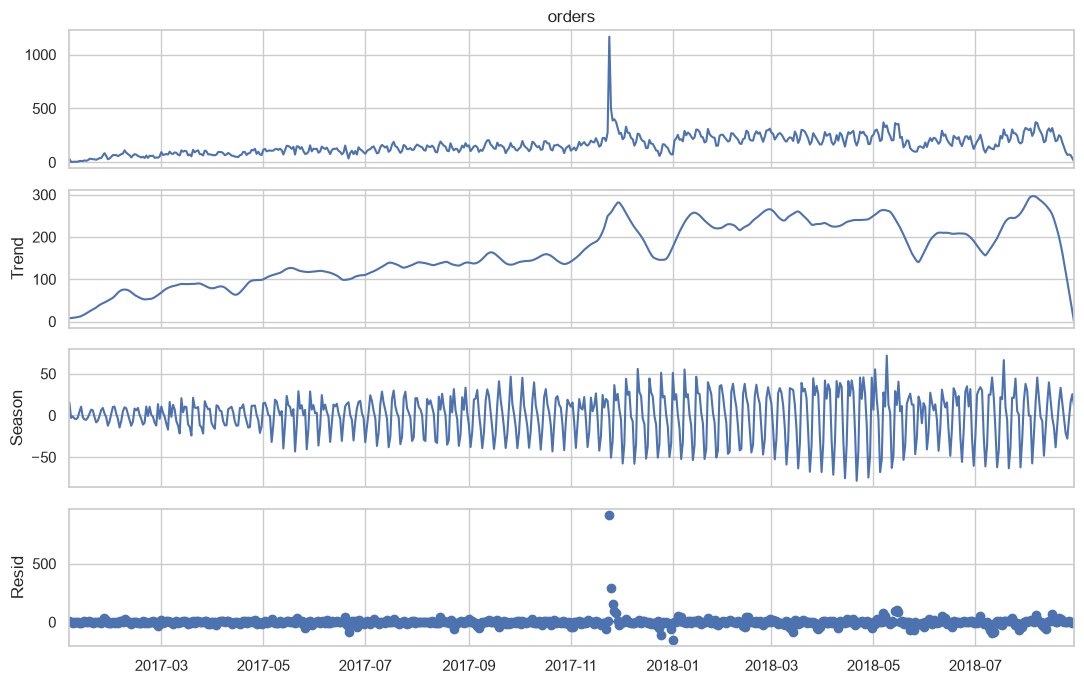

In [28]:
stl=STL(daily.astype(float),period=7,robust=True).fit(); fig=stl.plot(); fig.set_size_inches(11,7); save(fig,'stl_weekly.png')

Weekly STL uses **period 7 days**; it does not estimate a yearly cycle.

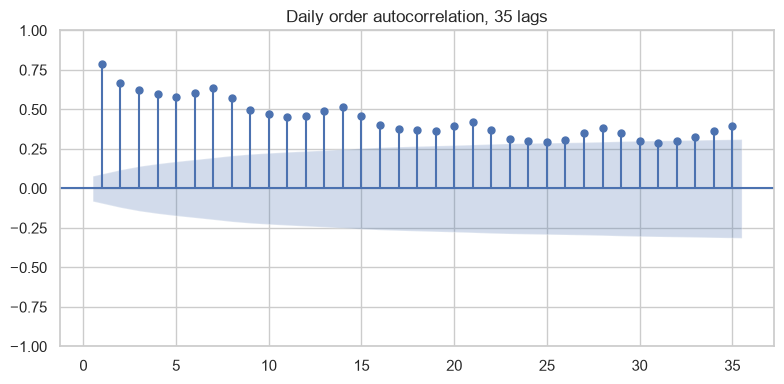

In [29]:
fig,ax=plt.subplots(figsize=(8,4)); plot_acf(daily,lags=35,ax=ax,zero=False); ax.set(title='Daily order autocorrelation, 35 lags'); save(fig,'daily_acf.png')

Autocorrelation checks dependence through **35 daily lags** for Phase 11.

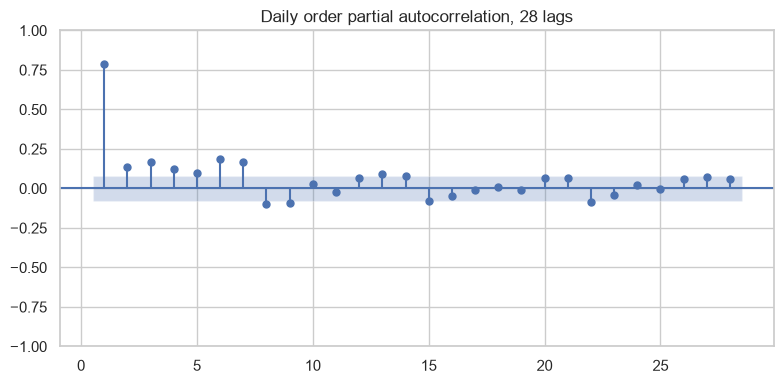

In [30]:
fig,ax=plt.subplots(figsize=(8,4)); plot_pacf(daily,lags=28,method='ywm',ax=ax,zero=False); ax.set(title='Daily order partial autocorrelation, 28 lags'); save(fig,'daily_pacf.png')

Partial autocorrelation checks direct dependence through **28 daily lags**.

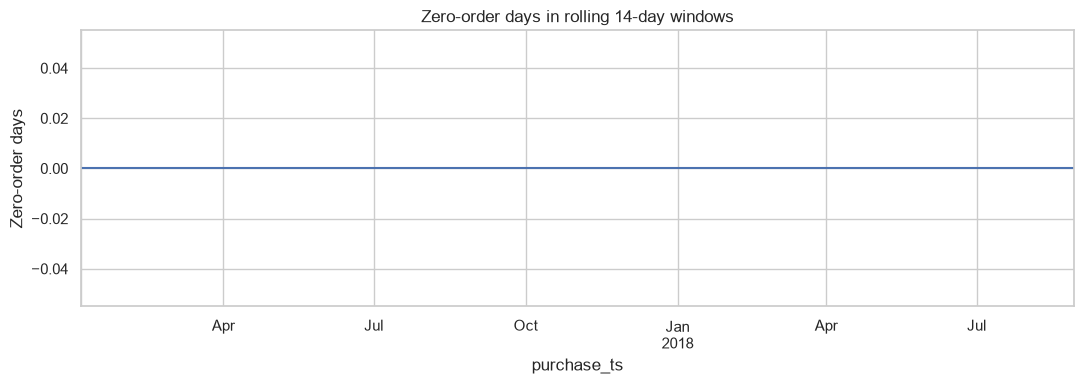

In [31]:
gaps=daily.eq(0).astype(int).rolling(14,min_periods=1).sum(); fig,ax=plt.subplots(figsize=(11,4)); gaps.plot(ax=ax); ax.set(title='Zero-order days in rolling 14-day windows',ylabel='Zero-order days'); save(fig,'daily_gaps.png')

A **14-day rolling count** surfaces gaps without inventing orders.

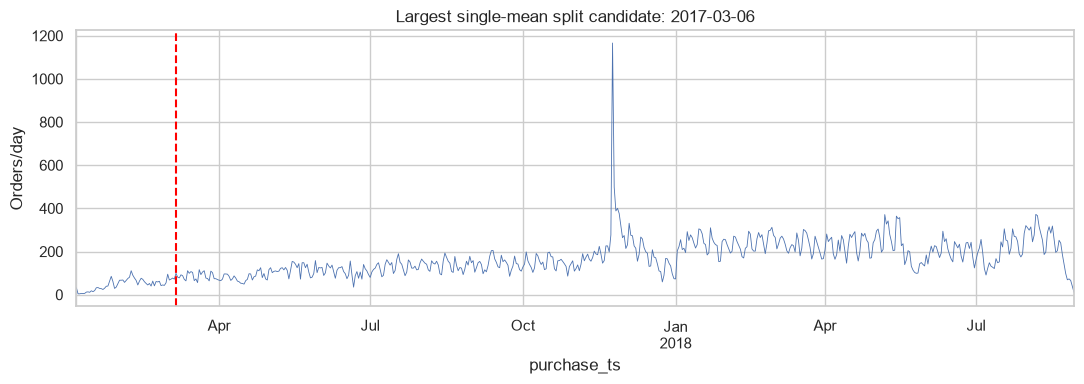

In [32]:
a=daily.to_numpy(dtype=float); candidates=range(60,len(a)-60); split=max(candidates,key=lambda i:abs(a[:i].mean()-a[i:].mean())); date=daily.index[split]
fig,ax=plt.subplots(figsize=(11,4)); daily.plot(ax=ax,lw=.6); ax.axvline(date,color='red',ls='--'); ax.set(title=f'Largest single-mean split candidate: {date:%Y-%m-%d}',ylabel='Orders/day'); save(fig,'structural_break_candidate.png')

The structural scan identifies **one candidate mean shift**; promotions and coverage changes can mimic breaks.

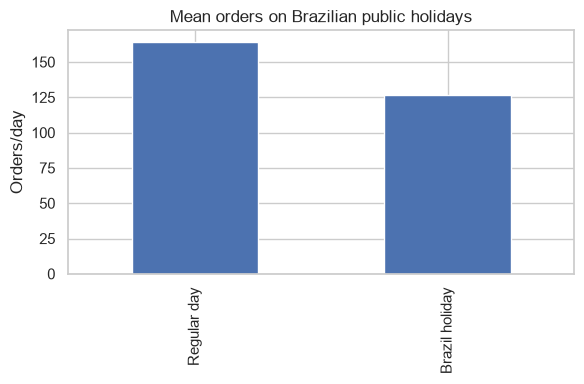

In [33]:
try:
 import holidays
 years=range(pd.Timestamp(ANALYSIS_START).year,pd.Timestamp(ANALYSIS_END).year+1)
 br=holidays.country_holidays('BR',years=years); holiday=daily.index.normalize().isin(pd.DatetimeIndex(br.keys()))
 hm=daily.groupby(holiday).mean().rename(index={False:'Regular day',True:'Brazil holiday'})
except ImportError:
 hm=pd.Series(dtype=float)
fig,ax=plt.subplots(figsize=(6,4)); hm.plot.bar(ax=ax); ax.set(title='Mean orders on Brazilian public holidays',ylabel='Orders/day'); save(fig,'holiday_effects.png')

Holiday comparisons cover **about 20 months** and remain descriptive rather than causal.

## Statistical comparisons

Each result includes effect size and sample size. Large samples can make tiny effects significant; judge practical value from effects.

In [34]:
review_order=reviews.drop_duplicates('order_id').set_index('order_id')
joined=orders.set_index('order_id').join(review_order[['review_score']])
late=joined.dropna(subset=['is_late','review_score'])
test_first=customers.sort_values('purchase_ts').drop_duplicates('customer_unique_id').copy()
cnt=customers.groupby('customer_unique_id').order_id.nunique(); test_first['repeat']=test_first.customer_unique_id.map(cnt).gt(1)
firstcat=interactions.sort_values('purchase_ts').drop_duplicates(['customer_unique_id','order_id']).drop_duplicates('customer_unique_id')
test_first=test_first.merge(firstcat[['customer_unique_id','category_en']],on='customer_unique_id',how='left')
delay=joined.dropna(subset=['delay_days','review_score'])
results=[
 mann_whitney_effect(late.loc[late.is_late,'review_score'],late.loc[~late.is_late,'review_score'],'Late vs on-time review score'),
 mann_whitney_effect(test_first.loc[test_first.repeat,'item_revenue'],test_first.loc[~test_first.repeat,'item_revenue'],'Repeat vs one-time first-order value'),
 category_repeat_test(test_first.category_en,test_first.repeat),
 lateness_repeat_test(test_first.is_late,test_first.repeat),
 delay_score_spearman(delay.delay_days,delay.review_score)]
test_results=pd.DataFrame(results)
display(test_results[['test','statistic','p_value','effect_size','n','interpretation']].style.format({'statistic':'{:.4f}','p_value':'{:.3g}','effect_size':'{:.4f}'}))

,test,statistic,p_value,effect_size,n,interpretation
0,Late vs on-time review score,150207354.5000,0,-0.5537,95560,Statistical evidence is present; assess the effect size and practical value.
1,Repeat vs one-time first-order value,121170718.5000,0.000639,-0.0379,93104,Statistical evidence is present; assess the effect size and practical value.
2,Chi-square category vs repeat,396.1083,2.84e-52,0.0657,91782,Statistical evidence is present; assess the effect size and practical value.
3,Fisher exact: first-order lateness vs repeat,0.8133,0.00614,0.8133,93096,The odds ratio compares repeat odds for late vs on-time first orders; Statistical evidence is present; assess the effect size and practical value.
4,Spearman: delivery delay vs review score,-0.1767,0,-0.1767,95560,Statistical evidence is present; assess the effect size and practical value.


## Phase 7 and 8 handoff

- **Features:** customer recency, frequency, merchandise-only monetary value; item/category popularity; delivery duration and estimate gap; missingness flags; calendar lags.
- **Drop from model inputs:** raw customer/order/product identifiers, review bodies unless designed as separate NLP features, and post-outcome fields unavailable at prediction time.
- **Transformations:** log1p for skewed spend/price/counts; fit capping thresholds on training folds and retain uncapped values for reports. Preview uses 1st/99th percentiles.
- **Encoding:** chronological training-only category mapping, rare-category grouping, and an unknown bucket.
- **Snapshot/horizon:** only 2,789 of 93,104 buyers repeat (3.00%); define label horizon and snapshots, and report prevalence and precision-recall rather than accuracy alone.
- **Forecasting:** 20 months supports weekly patterns but not annual seasonality.
- **Risks:** one-time buyers dominate, review text is missing for most reviews, and post-purchase delivery/review fields can leak target outcomes.